In [1]:
MODEL_SAVE_PATH = "/Users/giogonzales/Documents/ml-prep/ML-PREP-2025/learn/trainedWeights/trainedCotabatoPhase7/historical/v6.1"
FILE_PATH = "~/Documents/ml-prep/ML-PREP-2025/learn/data/SU_17_training_v3_contri.gpkg"
BASE_PATH = "~/Documents/ml-prep/ML-PREP-2025/learn/data"

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

# Import necessary packages and modules
from cv2 import add
import geopandas as gpd 
from py_files.data import preprocessing
from py_files.train_rainfall import train_model_rainfall
from py_files.GallenModel_v1 import CohesionLayer
from py_files.helpers import map_soil_type_to_conductivity, add_soil_type_index

In [3]:
df = gpd.read_file(FILE_PATH)
df.columns, df['LITHO'].head(), df['LITHODESC'].head(), df['Geomorphology'].unique(), df['LITHO'].unique(), df['type'].unique(), df['ContributingFactor_mean'].describe()

(Index(['DN', 'BD_mean', 'Clay_mean', 'Sand_mean', 'Silt_mean', 'NDVI_mean',
        'Est_mean', 'Nrt_mean', 'HorCurv_mean', 'VertCurv_mean', 'Slope_mean',
        'Elev_mean', 'SoilThc_mean', 'DistFlt_min', 'LULC_majority', 'TWI_mean',
        'PGA2_max', 'PGA1_max', 'Prc_mean', 'Distrv_min', 'distrd_min',
        'Soil Type', 'BUK_mean', 'landslide', 'landslide_probability',
        'landslide_preds', 'confusion', 'sus_pinn_landslide',
        'sus_pinn_ground truth', 'ds', 'cohesion', 'internal_friction',
        'descriptio', 'type', 'Landslide1', 'LITHO', 'LITHODESC', 'Lithology',
        'Geomorphology', 'LITHO_2', 'LITHODESC_2', 'value',
        'ContributingFactor_mean', 'geometry'],
       dtype='object'),
 0    Marine clastics, pyroclastics
 1    Marine clastics, pyroclastics
 2    Marine clastics, pyroclastics
 3    Marine clastics, pyroclastics
 4    Marine clastics, pyroclastics
 Name: LITHO, dtype: object,
 0    Marine clastics overlain by pyroclastics and t...
 1    Mari

In [4]:
df, columns, numeric_cols = preprocessing(df, columns_drop=['Landslide1', 'descriptio', 'sus_pinn_ground truth', 'ds', 'cohesion', 'internal_friction', 'sus_pinn_landslide', 'confusion', 'landslide_preds', 'landslide_probability', 'Lithology', 'LITHO', 'Geomorphology', 'LITHODESC', 'LITHO_2', 'LITHODESC_2', 'value'])
df, columns, numeric_cols

(           DN     BD_mean   Clay_mean   Sand_mean   Silt_mean  NDVI_mean  \
 0      365207  117.000000  359.000000  358.000000  283.000000   0.613077   
 1      365194  117.000000  359.000000  358.000000  283.000000   0.574141   
 2      364846  116.000000  363.245870  353.049174  283.704956   0.850096   
 3      366179  118.977409  364.217104  346.104510  289.678386   0.706061   
 4      365014  116.000000  354.000000  346.000000  300.000000   0.812694   
 ...       ...         ...         ...         ...         ...        ...   
 60589  365999  129.666667  328.333333  307.666667  364.333333   0.761467   
 60590  365726  129.466194  334.533806  310.834516  354.631678   0.728795   
 60591  365545  131.000000  333.000000  307.000000  360.000000   0.732718   
 60592  365172  134.000000  338.000000  301.000000  361.000000   0.848929   
 60593  365551  130.825443  336.849639  311.974756  352.038206   0.834761   
 
        Est_mean  Nrt_mean  HorCurv_mean  VertCurv_mean  ...  PGA1_max  \


In [5]:
df = add_soil_type_index(df[columns])
df.columns, df.head()

/Users/giogonzales/Documents/ml-prep/mlprep/py_files/helpers.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['soil_type_idx'] = df['type'].map(SOIL_TYPE_TO_IDX).fillna(2).astype(int)


(Index(['Clay_mean', 'Sand_mean', 'Silt_mean', 'NDVI_mean', 'Est_mean',
        'Nrt_mean', 'HorCurv_mean', 'VertCurv_mean', 'Slope_mean', 'Elev_mean',
        'SoilThc_mean', 'DistFlt_min', 'LULC_majority', 'TWI_mean', 'PGA1_max',
        'Prc_mean', 'Distrv_min', 'distrd_min', 'BUK_mean', 'landslide', 'type',
        'ContributingFactor_mean', 'soil_type_idx'],
       dtype='object'),
     Clay_mean   Sand_mean   Silt_mean  NDVI_mean  Est_mean  Nrt_mean  \
 0  359.000000  358.000000  283.000000   0.613077 -0.773640 -0.626037   
 1  359.000000  358.000000  283.000000   0.574141 -0.754606 -0.647454   
 2  363.245870  353.049174  283.704956   0.850096  0.851433  0.522159   
 3  364.217104  346.104510  289.678386   0.706061  0.559604 -0.805492   
 4  354.000000  346.000000  300.000000   0.812694 -0.515162 -0.852761   
 
    HorCurv_mean  VertCurv_mean  Slope_mean   Elev_mean  ...  TWI_mean  \
 0      0.037637       0.010312   23.168816  407.328140  ...  2.233544   
 1      0.041665      

2026-03-09 10:51:38.365946: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-03-09 10:51:38.580443: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-03-09 10:51:38.998427: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-03-09 10:51:39.823589: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-03-09 10:51:41.477767: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


dtype is a string
[<KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Clay_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Sand_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Silt_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=NDVI_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Est_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Nrt_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=HorCurv_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=VertCurv_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Slope_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Elev_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, na

2026-03-09 10:52:20.636013: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


dtype is a string
[<KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Clay_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Sand_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Silt_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=NDVI_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Est_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Nrt_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=HorCurv_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=VertCurv_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Slope_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Elev_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, na

2026-03-09 10:54:24.431947: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


dtype is a string
[<KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Clay_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Sand_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Silt_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=NDVI_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Est_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Nrt_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=HorCurv_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=VertCurv_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Slope_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, name=Elev_mean>, <KerasTensor shape=(None, 1), dtype=float32, sparse=False, ragged=False, na

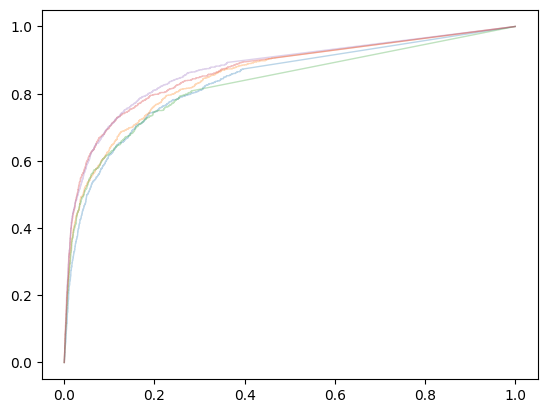

In [6]:
train_model_rainfall(df, numeric_cols + ['soil_type_idx'], ['type'], columns + ['soil_type_idx'], "PGA1_max", MODEL_SAVE_PATH)

In [7]:
from tensorflow.keras.models import load_model
from py_files.GallenModel_v1 import InternalFrictionLayer, NewmarkActivation
from py_files.LandslideRainfall import LandslideRainFall
model = load_model(f"{MODEL_SAVE_PATH}/fold-1-model-0.keras", custom_objects={
    "CohesionLayer":CohesionLayer,
    "NewmarkActivation":NewmarkActivation,
    "InternalFrictionLayer": InternalFrictionLayer,
   
})

In [8]:
from py_files.data import dataframe_to_dataset


validation_df = gpd.read_file(FILE_PATH)
validation_df = add_soil_type_index(validation_df)

#:((
column_map = {
    "Geomorph":"Geomorphology",
    "LITHODESC_2":"LITHODESC",
    "Soil Type":"type"
}
validation_df, columns, numeric_cols = preprocessing(validation_df, columns_drop=['Landslide1', 'descriptio', 'sus_pinn_ground truth', 'ds', 'cohesion', 'internal_friction', 'sus_pinn_landslide', 'confusion', 'landslide_preds', 'landslide_probability', 'Lithology', 'LITHO', 'Geomorphology', 'LITHODESC', 'LITHO_2', 'LITHODESC_2', 'value'])
validation_ds = dataframe_to_dataset(validation_df[columns], shuffle=False, batch_size=128)

466/466 ━━━━━━━━━━━━━━━━━━━━ 1s 865us/step
466/466 ━━━━━━━━━━━━━━━━━━━━ 1s 875us/step
466/466 ━━━━━━━━━━━━━━━━━━━━ 1s 928us/step


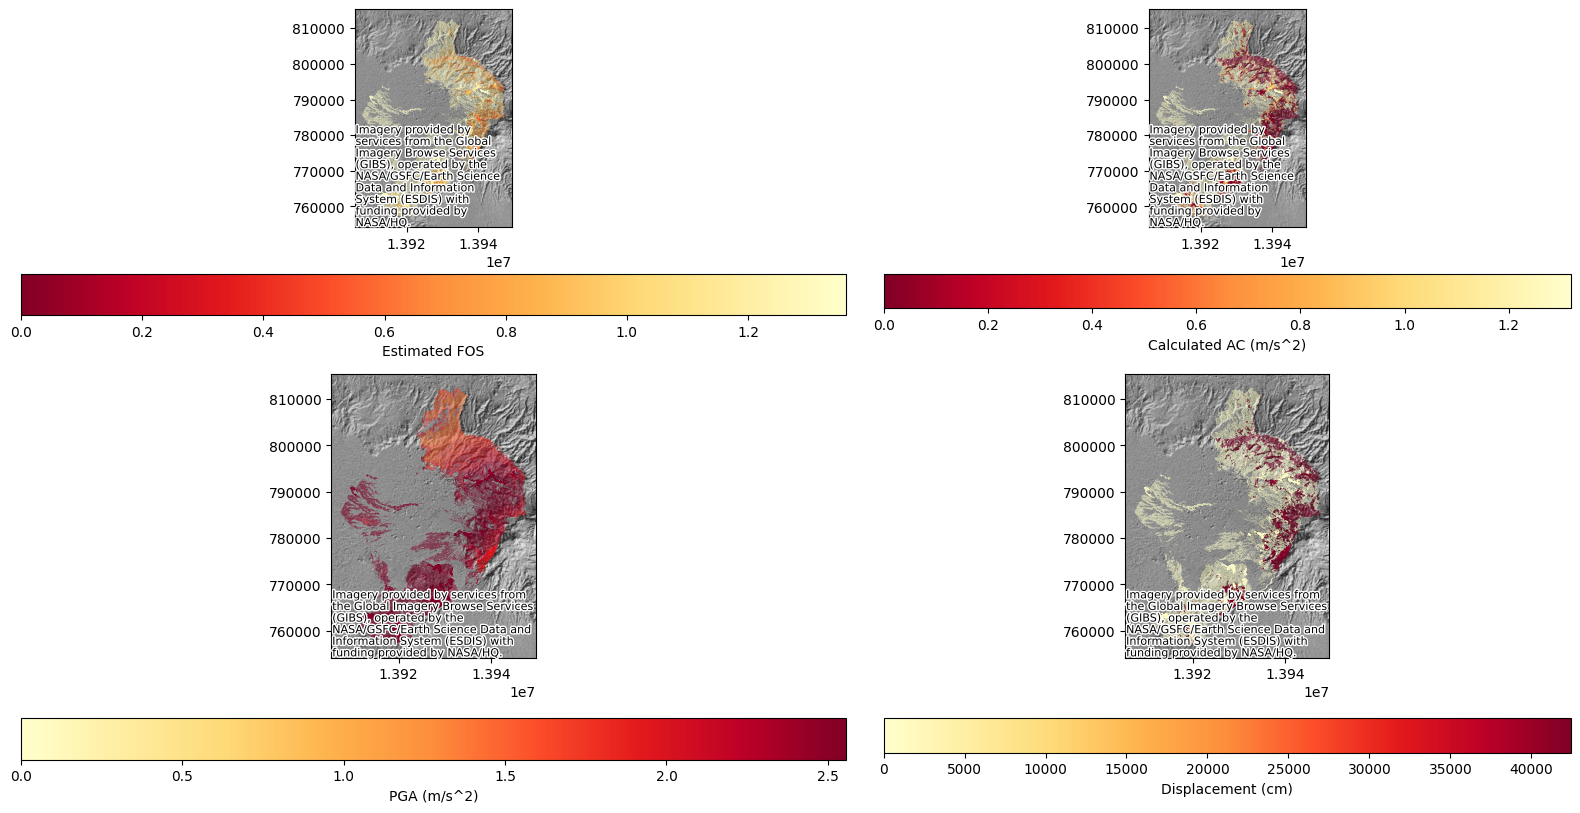

In [9]:
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
from matplotlib import pyplot as plt
import numpy as np
import tensorflow as tf
import contextily as cx
fig = plt.figure(figsize=(20, 10))

gs = fig.add_gridspec(
    2, 2,
    width_ratios=[1.2, 1],   # columns
    height_ratios=[1, 1.3],  # rows
    wspace=0.05,
    hspace=0.15
)

ax = np.array([
    [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])],
    [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])]
])

df_wm = validation_df.to_crs(epsg=3857)
fos_model = tf.keras.Model(inputs=model.inputs, outputs=model.get_layer("fos_layer").output)
predicted_fos = fos_model.predict(validation_ds)
df_wm['estimated_fos'] = predicted_fos

norm = mcolors.Normalize(vmin=0, vmax=df_wm['estimated_fos'].median())
df_wm.plot(column="estimated_fos", legend=True, alpha=0.7, norm=norm, ax=ax[0][0], cmap='YlOrRd_r', legend_kwds={"label": "Estimated FOS", "orientation": "horizontal"})
cx.add_basemap(ax=ax[0][0],source='NASAGIBS.ASTER_GDEM_Greyscale_Shaded_Relief')

ac_model = tf.keras.Model(inputs=model.inputs, outputs=model.get_layer('critical_acceleration').output)
predicted_acceleration = ac_model.predict(validation_ds)

df_wm['slope_radians'] = df_wm['Slope_mean'] * 0.017453292519943295
df_wm['calculated_ac'] = (df_wm['estimated_fos'] - 1) * 9.81 * np.sin(df_wm['slope_radians'])
df_wm['estimated_ac'] = predicted_acceleration[0]

# df_wm['calculated_ac'] = df_wm['calculated_ac'] / 9.81

ac_norm = mcolors.Normalize(vmin=0, vmax=df_wm['calculated_ac'].median())

df_wm.plot(column="estimated_ac", legend=True, alpha=0.7, norm=ac_norm, ax=ax[0][1], cmap='YlOrRd_r', legend_kwds={"label": "Calculated AC (m/s^2)", "orientation": "horizontal"})
cx.add_basemap(ax=ax[0][1],source='NASAGIBS.ASTER_GDEM_Greyscale_Shaded_Relief')

# displacement_model = tf.keras.Model(inputs=model.inputs, outputs=model.get_layer("modified_fos_displacement").output)
# predicted_ds = displacement_model.predict(validation_ds)
# df_wm['estimated_displacement'] = predicted_ds[0]

df_wm['PGA1_max'] *= 9.81
ac_norm = mcolors.Normalize(vmin=0, vmax=df_wm['PGA1_max'].median())
df_wm.plot(column="PGA1_max", legend=True, alpha=0.7, norm=ac_norm, ax=ax[1][0], cmap="YlOrRd", legend_kwds={"label": "PGA (m/s^2)", "orientation": "horizontal"})
cx.add_basemap(ax=ax[1][0],source='NASAGIBS.ASTER_GDEM_Greyscale_Shaded_Relief')

df_wm['acpg'] = predicted_acceleration[1]

displacement_model = tf.keras.Model(inputs=model.inputs, outputs=model.get_layer("displacement_layer").output)
predicted_displacement = displacement_model.predict(validation_ds)
df_wm['estimated_ds'] = predicted_displacement

ac_norm = mcolors.Normalize(vmin=0, vmax=df_wm['estimated_ds'].quantile(0.95))
df_wm.plot(column='estimated_ds', legend=True, alpha=0.7, ax=ax[1][1], cmap="YlOrRd", norm=ac_norm,  legend_kwds={"label": "Displacement (cm)", "orientation": "horizontal"})
cx.add_basemap(ax=ax[1][1],source='NASAGIBS.ASTER_GDEM_Greyscale_Shaded_Relief',) 


466/466 ━━━━━━━━━━━━━━━━━━━━ 1s 901us/step


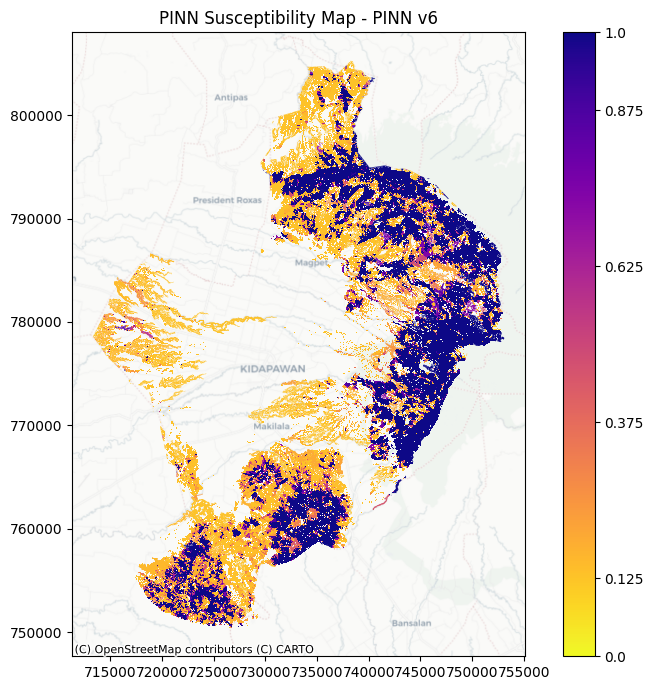

In [10]:
from py_files.metrics import plot_susceptibility_map

susceptibility_prediction = model.predict(validation_ds)
plot_susceptibility_map(validation_df, susceptibility_prediction, "PINN v6")

466/466 ━━━━━━━━━━━━━━━━━━━━ 1s 843us/step
Predicted cohesion length: 59562


(np.float32(0.063702255), np.float32(2.197455))

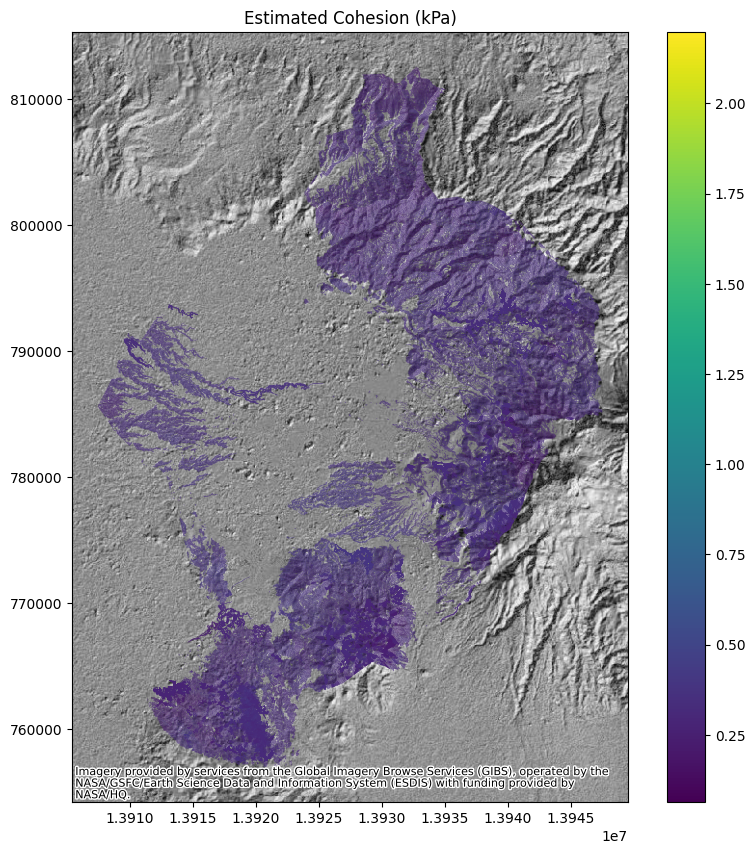

In [16]:
#Extract Geotechnical estimation of the model
df_wm = validation_df.to_crs(epsg=3857)
cohesion_model = tf.keras.Model(inputs=model.inputs, outputs=model.get_layer("cohesion_clip").output)
predicted_cohesion = cohesion_model.predict(validation_ds)
df_wm['estimated_cohesion'] = predicted_cohesion

ax = df_wm.plot(column="estimated_cohesion", legend=True, figsize=(10, 10), alpha=0.7)
ax.set_title("Estimated Cohesion (kPa)")
cx.add_basemap(ax,source='NASAGIBS.ASTER_GDEM_Greyscale_Shaded_Relief')
print(f"Predicted cohesion length: {len(predicted_cohesion)}")
df_wm['estimated_cohesion'].min(), df_wm['estimated_cohesion'].max()


466/466 ━━━━━━━━━━━━━━━━━━━━ 0s 832us/step
Predicted I length: 59562


(np.float32(0.46623993), np.float32(0.6671899))

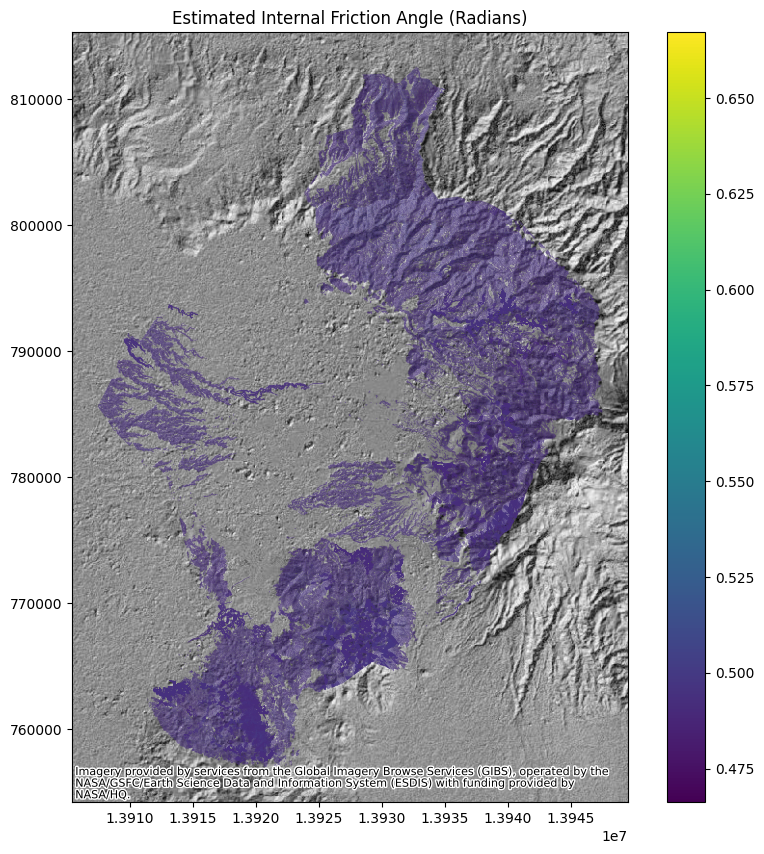

In [17]:
#Extract Geotechnical estimation of the model
df_wm = validation_df.to_crs(epsg=3857)
ifi_model = tf.keras.Model(inputs=model.inputs, outputs=model.get_layer("ifi_clip").output)
predicted_ifi = ifi_model.predict(validation_ds)
df_wm['estimated_ifi'] = predicted_ifi

ax = df_wm.plot(column="estimated_ifi", legend=True, figsize=(10, 10), alpha=0.7)
ax.set_title("Estimated Internal Friction Angle (Radians)")
cx.add_basemap(ax,source='NASAGIBS.ASTER_GDEM_Greyscale_Shaded_Relief')
print(f"Predicted I length: {len(predicted_ifi)}")
df_wm['estimated_ifi'].min(), df_wm['estimated_ifi'].max()


466/466 ━━━━━━━━━━━━━━━━━━━━ 0s 470us/step
Predicted wetness length: 59562


(np.float32(0.035378), np.float32(0.5))

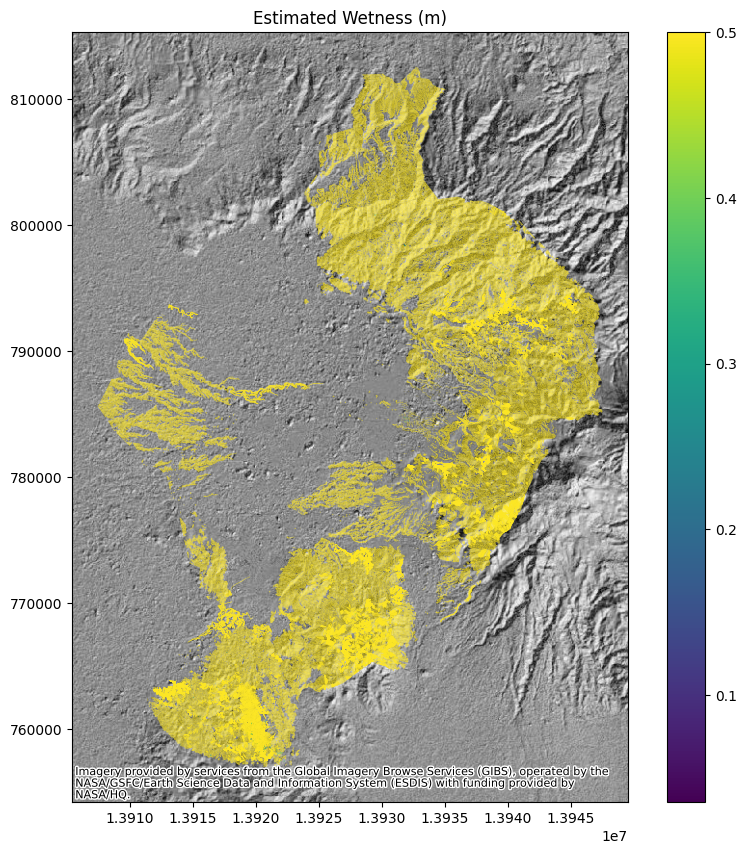

In [18]:
#Extract Geotechnical estimation of the model
df_wm = validation_df.to_crs(epsg=3857)
wetness_model = tf.keras.Model(inputs=model.inputs, outputs=model.get_layer("m_clip").output)
predicted_wetness = wetness_model.predict(validation_ds)
df_wm['estimated_wetness'] = predicted_wetness

ax = df_wm.plot(column="estimated_wetness", legend=True, figsize=(10, 10), alpha=0.7)
ax.set_title("Estimated Wetness (m)")
cx.add_basemap(ax,source='NASAGIBS.ASTER_GDEM_Greyscale_Shaded_Relief')
print(f"Predicted wetness length: {len(predicted_wetness)}")
df_wm['estimated_wetness'].min(), df_wm['estimated_wetness'].max()


In [19]:
layer = model.get_layer("hydraulic_conductivity")

u_k = layer.get_weights()[0]
print("u_k:", u_k)

u_k: [0.00174687 0.         0.00136036]


In [ ]:
import tensorflow as tf

layer = model.get_layer("hydraulic_conductivity")

u_k = layer.u_k.numpy()
k_min = layer.k_min.numpy()
k_max = layer.k_max.numpy()

k_cms = k_min + (k_max - k_min) * tf.nn.sigmoid(u_k).numpy()

print("K (cm/s) per soil type:", k_cms)